# Introduction

## Bistable perception, Filling in, and Content Addressable Memories

In this project we will implement a simple model of bistable perception via the Hopfield networks [1], some of the simplest recurrent neural networks, which performs the function of 'content addressable memory'. That is, given an incomplete pattern, neurons 'autocomplete' the pattern. Each pattern is stored as a fixed point attractor via Hebbian learning. This type of network can also 'denoise' a known stimulus. It has also been used to explain 'filling in' phenomenon.

>Bistable perception is when the brain cannot decide what is the correct interpretation of a picture and spontaneously switches between interpretations. Filling in happens when the brain 'fills in' for a stimulus that has not been seen, but is implied (such as the Gazzaniga triangle and certain color ilusions).

[1]	J. Hopfield, “Neural networks and physical systems with collective emergent computational abilities,” proceedings of the national academy of sciences (Biophysics), Apr. 1982.


## Learning Goals

- Implement a Hopfield recurrent neural network (RNN)
- Train the network with 'one shot' Hebbian learning
- Relate the activity of the network with fixed point attractors of the newtork
- Explain what is an energy function
- Reason about the energy landscape of Hopfield Networks

## A Hopfield Network

The Hopfield network belongs to a type of algorithms called *autoassociative* and they can store information in memory to retrieve/recall it later with incomplete input patterns. The patterns are imprinted in the weight matrix and due to its constraints (symmetric connections), an input will lead to dynamics that eventually will settle in one of the stored patterns. In dynamical systems lingo, an 'attractor'.

Thus, given a cue, a Hopfield network can restore a stored pattern, in a phenomenon called 'content addressable memory'.

The Hopfield network is defined as follows:

---
$$a_j \leftarrow \left\{\begin{array}{ll} +1 & \mbox {if }\sum_{j}{w_{ij}a_i}\geq\theta, \\
 -1 & \mbox {otherwise.}\end{array}\right.$$
 
---

where:
- $w_{ij}$ is the strength of the connection weight from unit j to unit i (the weight of the connection). In the Hopfield network, all weights are **symmetric**, that is $w_{ij} = w_{ji}$. Weights are real numbers (positive or negative decimals). Self-connections are not allowed.
- $a_j$ is the *state* of unit j.
- $\theta$ is the threshold, we use $0$ in this project.

Notes:
- Every neuron receives input from every other neuron and also outputs information to every other neuron.
  - There are no self-connections
- Each neuron is a perceptron with a +1/-1 output
- Alternatively, activities may also be either 0 or 1 (instead of -1 and 1). 
- The update of the units can be both synchronous (all $a_i$ are updated simultaneously) or asynchronous. In this project we will implement synchronous updates.

## Hopfield example 



This is a possible starting configuration of a Hopfield network. Each line or edege represents a weighted connection between nodes (a real number). The activation of nodes can take values of either +1 or -1 according to the Hopfield network.

<div>
<img src=http://drive.google.com/uc?export=view&id=1sev0wqUI27o2nS7zMitfDa_CSvy1o4Hz width="500">
</div>

At each timestep, a neuron receives an incoming "field", which is the weighted sum of the output of all other neurons. A neuron ***flips*** if the weighted sum of the outputs of the other neurons is the opposite sign. If the sign is equal to its own sign however, nothing changes.

---

Let's look at the evolution of the state vector in this Hopfield network.

The inputs the top neuron gets are (from left to right):

$$
-1 * +1 = -1 \\
-1 * -1 = +1 \\
\text{+ and - cancel each other out} \\
+1 * +1 = +1 \\
\rule{3cm}{0.4pt} \\
\qquad +1
$$

which is opposite to $-1$, so the sign of this neuron will change!

Thus, these are the states of the network after one timestep, or one **evolution**

<div>
<img src=http://drive.google.com/uc?export=view&id=1ZOHlytgk9MNgAQiE3THXWyIHLFbuB5J5 width="350">
</div>


## 1. Hopfield for one evolution

____
> **Exercise 1.** Implement a function that computes the evolution of the state of a recurrent neural network.
____

### Excercise 1: ANSWERS

### option 1: using sum notation

In [0]:
# import dependencies
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact
from IPython.display import display
import networkx as nx

np.random.seed(1)

In [0]:
def RNN_one(W,state):
  '''
  Returns the evolution of a given state
  '''
  new_state = [] # to append new state to
  SUM = 0 # start with zero SUM

  for j in range(len(state)):
      a_j = state[j] # a_j is the state of a neuron in the network
      print(f'state of neuron j={j}: {a_j}')
      # calculate the weighted sum of all inputs (a_i's) to that neuron, a_j (from = rows, to = cols) 
      for i in range(len(state)):
        SUM += W[i,j] * state[i] # add weighted input
  
      if SUM > 0:
        a_j = 1 # state is +1
        new_state.append(a_j)
      else:
        a_j = -1 
        new_state.append(a_j)

      print(f'new state: {a_j}')
      print('---')

  return new_state

In [0]:
# create random initial state
state = np.array([-1,1,1,-1,-1])
W = np.outer(state,state)
np.fill_diagonal(W,0)

# call RNN_one function
RNN_one(W,state)

state of neuron j=0: -1
new state: -1
---
state of neuron j=1: 1
new state: -1
---
state of neuron j=2: 1
new state: 1
---
state of neuron j=3: -1
new state: -1
---
state of neuron j=4: -1
new state: -1
---


[-1, -1, 1, -1, -1]

### option 2: using matrices and vectors

In [0]:
def RNN_two(state):
  dim = len(state) # get dimension for matrix based on input patterns
  W = state.T@state# take outer product to obtain weight matrix
  np.fill_diagonal(W, 0) # remove self-connections
  
  return W

In [0]:
# call the Hopfield function to obtain adjacency matrix from input state
M_hop = RNN_two(np.array([[-1,1,1,-1,-1]]))

M_hop

array([[ 0, -1, -1,  1,  1],
       [-1,  0,  1, -1, -1],
       [-1,  1,  0, -1, -1],
       [ 1, -1, -1,  0,  1],
       [ 1, -1, -1,  1,  0]])

In [0]:
def get_newstate(state, threshold=0):

  # calculate new state by matrix inner product of hopfield matrix and new pattern
  s = M_hop@state
  s[s >= threshold] = 1
  s[s < threshold] = -1
  return s

# if the summed output > threshold ==> 1 else ==> -1
new_state= get_newstate(np.array([1,1,1,1,-1]))

new_state

array([-1,  1,  1, -1,  1])

## 2. The Necker cube and training

Here's some code that displays a Necker Cube, a prime example of bistability of perception. In general, human beings  either perceive a 3D cube with blue face in front and the red in the back or vice-versa, but not both in front simultaneously (incidentally, it is also possible to see a flat hexagon, though it is unlikely). Also, it is not possible to 'enforce' a particular perception, and the interpretations switch between the two possible states.

The rationale of this type of bistability in the interpretation of 3D objects is that by looking at many examples of surfaces in the world, you have 'trained' your visual system to perceive the world in ways that are consistent/coherent. 



### Open draw graph code

In [0]:
def draw_graph(state):

  G=nx.cubical_graph()
  pos=nx.spring_layout(G, seed=0) # positions for all nodes
  
  pos_nodes = []
  neg_nodes = []

  # get indices of positive and negative nodes
  for s in range(len(state)):
    if state[s] == 1:
      pos_nodes.append(s)
    else:
      neg_nodes.append(s)

  # draw nodes
  nx.draw_networkx_nodes(G,pos,
                        nodelist=pos_nodes,
                        node_color='b',
                        node_size=500,
                    alpha=0.8)
  nx.draw_networkx_nodes(G,pos,
                        nodelist=neg_nodes,
                        node_color='y',
                        node_size=500,
                    alpha=0.8)

  # edges
  nx.draw_networkx_edges(G,pos,width=1.0,alpha=0.5)
  nx.draw_networkx_edges(G,pos,
                        edgelist=[(0,1),(1,2),(2,3),(3,0)],
                        width=8,alpha=0.5,edge_color='k')
  nx.draw_networkx_edges(G,pos,
                        edgelist=[(4,5),(5,6),(6,7),(7,4)],
                        width=8,alpha=0.5,edge_color='k')
  # node labels
  labels={}
  labels[0]=r'$A$'
  labels[1]=r'$B$'
  labels[2]=r'$C$'
  labels[3]=r'$D$'
  labels[4]=r'$E$'
  labels[5]=r'$F$'
  labels[6]=r'$G$'
  labels[7]=r'$H$'
  nx.draw_networkx_labels(G,pos,labels,font_size=16)

  plt.axis('off')
  plt.savefig("labels_and_colors.png") # save as png
  plt.show() # display

### Oneshot learning

Hopfield networks can be trained with 'one shot learning', that is, we directly calculate the final weights from the training patterns.

In the Neckercube above, each vertex represents a **node** in the Hopfield network, which has a state of `-1` or `1`.


---

**Exercise 2.** Train the network via Hebbian learning with two patterns / states.

---



To train a Hopfield network we use the Hebbian learning rule, as such:

---
$$ w_{ij}=\frac{1}{n}\sum_{\mu=1}^{n}\epsilon_{i}^\mu \epsilon_{j}^\mu $$

---
where:

- $\epsilon$ is a vector encoding a 'pattern'  that we want to train. In a Hopfield network the size of the pattern is the same as the size of the network itself.
- $\mu$ is the index of one of the (potentially many) binary patterns we want to train. $\epsilon^\mu_i$ is the desired pattern activity for neuron $i$ pattern $\epsilon^\mu$. 

---

**NOTE**: the weight matrix is just computed once from the input pattern(s). The only thing that is updated is the state. The state will change (evolve) over time and eventually settle to the state with the least amount of energy.



### Answer Exercise 2 

In [0]:
# make state 1 (hidden G)
s1 = np.array((1,1,1,1,1,1,-1,1))
# make state 2 (hidden A)
s2 = np.array((-1,1,1,1,1,1,1,1))

# put them together
states = np.array((s1,s2))

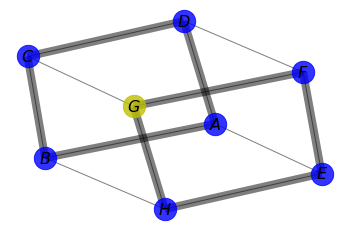

In [0]:
# This is how the neckercube looks with s1: yellow is -1, blue is +1
draw_graph(s1)

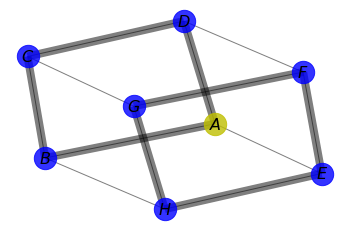

In [0]:
# and for state 2
draw_graph(s2)

The function below (`Hopfield`) uses the two states to get the trained weight matrix.


In [0]:
def Hopfield(states, threshold=0):
  dim = states.shape[-1] # get dimension for matrix based on size of input vectors
  # start with a randomised network according to instructions
  mu, sigma = 0, 1
  W = np.random.normal(mu, sigma, size=(dim,dim))
  W0 = W.copy() # initial weight matrix

  # state by state "oneshot training"
  for s in states:
      W_init = np.outer(s,s) # take outer product to obtain weight matrix for timestep
      np.fill_diagonal(W_init, 0) # remove self-connections
      W = W + W_init # get the new matrix

  # normalize the weight matrix (make elements -1,0, or 1 only)
  W[W > threshold] = 1 
  W[W < threshold] = -1
  np.fill_diagonal(W,0)
  return W0, W

In [0]:
W0, W_trained = Hopfield(states) # save the trained and initial matrix

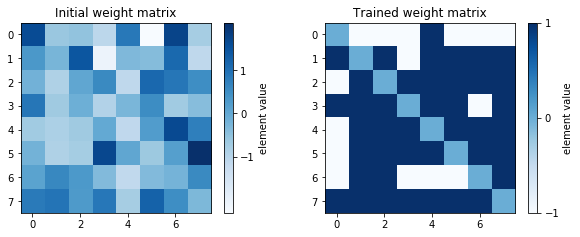

In [0]:
# subplot with initial and trained weight matrix
plt.figure(figsize=(10, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(W0, cmap='Blues')
plt.title('Initial weight matrix')
plt.colorbar(ticks=[-1,0,1], label='element value');

plt.subplot(1, 2, 2)
plt.imshow(W_trained, cmap='Blues')
plt.title('Trained weight matrix')
plt.colorbar(ticks=[-1,0,1], label='element value');

## 3. Convergence

---

**Exercise 3.** Observe the convergence to particular patterns / states from different initial conditions.

- Give random intial states to the trained network and observe the evolution of the network state
- Do that again! What do you observe?

---


In [0]:
# create some random initial states
s3 = np.array((-1,1,-1,1,-1,1,-1,1), dtype=int)
s4 = np.array((1,-1,-1,-1,-1,1,-1,1), dtype=int)
s5 = np.array((1,-1,1,1,-1,1,-1,1), dtype=int)

In [0]:
def get_anewstate(W_trained, state, timesteps, threshold=0):
  '''
  Returns new state given a random state.
  '''
  state_lst = []
  s = state # first, s is the random state

  for i in range(timesteps): # for a number of timesteps
    s = W_trained@s # new state is the inner product of the trained matrix and state
    s[s > threshold] = 1 # normalise state
    s[s < threshold] = -1
    state_lst.append(s) # save state to list to display later
  return state_lst

def inspect_states(timesteps,state_lst):
  '''
  Interactive slider to see how the state evolves.
  '''
  N = int(timesteps) # number of timesteps
  def view_states(t=0):
    draw_graph(state_lst[t])
  interact(view_states, t=(0, N-1))

Using the functions defined above, let's see what happens when we give our trained matrix a new state and let it run for a number of timesteps.

In [0]:
# get new state s3
state_lst_3 = get_anewstate(W_trained, s3,10)

In [0]:
inspect_states(10,state_lst_3)

interactive(children=(IntSlider(value=0, description='t', max=9), Output()), _dom_classes=('widget-interact',)…

In [0]:
# get new state s4
state_lst_4 = get_anewstate(W_trained, s4,10)
# inspect evolution of states
inspect_states(10,state_lst_4)

interactive(children=(IntSlider(value=0, description='t', max=9), Output()), _dom_classes=('widget-interact',)…

In [0]:
# get new state s5
state_lst_5 = get_anewstate(W_trained, s5,10)
inspect_states(10,state_lst_5)

interactive(children=(IntSlider(value=0, description='t', max=9), Output()), _dom_classes=('widget-interact',)…

## 4. Energy

The reason why the states tend to converge to one of the trained stimuli can be understood via a 'potential energy' metaphor. The energy landscape of a trained Hopfield network has minima at locations of the trained stimuli. We speak about a 'Negative Lyapunov Energy Function', to represent that. It can be shown that the level of energy of the Hopfield network (as described above) is always decreasing. Given an initial state the energy at time $t$ of the Hopfield network is computed as:

$$
E = -\frac{1}{2} \sum_i \sum_j w_{ij} a_i a_j
$$

which is equivalent to

$$
E = - \frac{1}{2} \mathbf{a}^T \mathbf{W} \mathbf{a}
$$


The network is going to evolve until it this energy term reaches a minimum. The energy is a convex quadratic, so the shape we can expect is a bowl going upwards.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/4/49/Energy_landscape.png/500px-Energy_landscape.png)

___ 

> **Exercise 4.** Show the evolution of the energy function for different initial conditions as above.

___

### Answer Exercise 4

We already have the evolution of states for 3 random initial states. The only thing that is left to do is calculating the energy for the state of each timestep, again, using the trained weight matrix.
We use the simple function below and our 3 states:

In [0]:
def compute_energy(state_evolution,W_trained):
  energy_evo = []
  for s in state_evolution: # for state in the state evolution
    E = -0.5 * (s.T@W_trained@s) # compute energy for that state
    energy_evo.append(E) 
    #print(E)
  return energy_evo

In [0]:
energy_evo_3 = compute_energy(state_lst_3,W_trained);

In [0]:
energy_evo_4 = compute_energy(state_lst_4,W_trained)

In [0]:
energy_evo_5 = compute_energy(state_lst_5,W_trained);

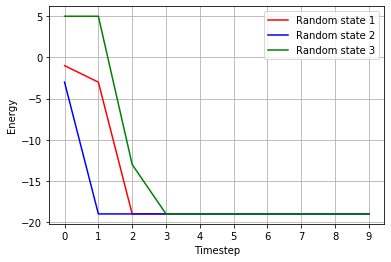

In [0]:
# timesteps
x_axis = [0,1,2,3,4,5,6,7,8,9]

# plot the energy per state
plt.plot(x_axis, energy_evo_3, 'r', label='Random state 1')
plt.plot(x_axis, energy_evo_4, 'b', label='Random state 2')
plt.plot(x_axis, energy_evo_5, 'g', label='Random state 3')
plt.xlabel('Timestep')
plt.ylabel('Energy')
plt.grid(True)
plt.xticks(x_axis);
plt.legend();

## Helpful Resources

- [Intro to Hopfield Networks](http://koaning.io/intro-to-hopfield-networks.html)
- [Neupy](http://neupy.com/2015/09/20/discrete_hopfield_network.html)
